In [51]:
# 모! 듈! 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # 어노바
from statsmodels.stats.multicomp import pairwise_tukeyhsd # 어노바 친구 튜키
from scipy.stats import chi2_contingency # 그리고 Chi-square
from scipy.stats import shapiro # 정규성 검정용
from scipy.stats import probplot # 큐큐플롯
import statsmodels.api as sm
from statsmodels.formula.api import ols

from matplotlib.colors import LinearSegmentedColormap # 컬러맵 커스터마이즈용

# 그래프 기본 테마 설정
sns.set_theme(palette="tab10", style="whitegrid", font_scale=1) # 블루톤

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Pretendard' # 프리텐다드
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14 # 기본 폰트사이즈 (자세한 양식은 하기)
plt.rcParams['axes.unicode_minus'] = False

# 그래프 공통 양식
# 1. 테마: tab10(기본)/히트맵: Blues
# 2. Font: 프리텐다드
# 3. 제목/라벨 크기: 16, 14(별도 설정이 있는 경우 12)
# 4. 제목 라벨: y = 1.03

In [52]:
# 일단 불러야 뭘 한다
bank_df = pd.read_csv('data/bank_preprocess.csv')
bank_df.drop('Unnamed: 0', axis=1, inplace=True) # 저장하다 문제 생긴 듯.. 

bank_df

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,deposit,age_group,previous_group,balance_group,campaign_group,H/L
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,1,-1,0,unknown,yes,50,new,plus,single_touch,HYLN
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,1,-1,0,unknown,yes,50,new,plus,single_touch,HNLN
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,1,-1,0,unknown,yes,40,new,plus,single_touch,HYLN
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,1,-1,0,unknown,yes,50,new,plus,single_touch,HYLN
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,2,-1,0,unknown,yes,50,new,plus,multi_touch,HNLN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,...,1,-1,0,unknown,no,30,new,plus,single_touch,HYLN
11158,39,services,married,secondary,no,733,no,no,unknown,16,...,4,-1,0,unknown,no,30,new,plus,multi_touch,HNLN
11159,32,technician,single,secondary,no,29,no,no,cellular,19,...,2,-1,0,unknown,no,30,new,plus,multi_touch,HNLN
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,...,2,172,5,failure,no,40,remarketing,zero,multi_touch,HNLY


# Chi-square
- deposit이 범주형이기때문에 anova가 불가능합니다. 

## 연령대별 가입비

In [53]:
# 20~50대/other(10대/60대 이상)
main_age_group = [20, 30, 40, 50] # 2, 3, 4, 50대
bank_df['group_category'] = bank_df['age_group'].apply(lambda x: f"{int(x)}대" if x in main_age_group else '기타(Others)') 

In [79]:
# 1. 교차표(Contingency Table) 생성
age_deposit_table = pd.crosstab(bank_df['group_category'], bank_df['deposit'])

print("--- 연령대별 가입 빈도 교차표 ---")
display(age_deposit_table)

# 2. 카이제곱 검정
chi2, p_val, dof, expected = chi2_contingency(age_deposit_table)

print(f"\n카이제곱 통계량: {chi2:.2f}") # 실제로 관측된 값이, ‘연령대와 가입 여부가 서로 무관하다’고 가정했을 때의 값에서 얼마나 크게 벗어났는지를 수치로 나타낸 것
print(f"p-value: {p_val}") # 그거 그거 그 0.05보다 작아야되는거 
print(f"자유도: {dof}")

# 3. 결과 해석
alpha = 0.05
if p_val < alpha:
    print(f"\n해석: p-value({p_val:.4e})가 0.05보다 작으므로, 연령대에 따른 가입 여부의 차이는 통계적으로 유의미합니다.")
else:
    print(f"\n해석: p-value({p_val:.4f})가 0.05보다 크므로, 연령대와 가입 여부는 독립적(차이 없음)이라고 볼 수 있습니다.")

--- 연령대별 가입 빈도 교차표 ---


deposit,no,yes
group_category,,
10대,3,18
20대,620,910
30대,2405,1913
40대,1565,1063
50대,1100,785
기타(Others),180,600



카이제곱 통계량: 467.15
p-value: 9.807050181650491e-99
자유도: 5

해석: p-value(9.8071e-99)가 0.05보다 작으므로, 연령대에 따른 가입 여부의 차이는 통계적으로 유의미합니다.


In [55]:
cont_table = pd.crosstab(bank_df['group_category'], bank_df['deposit'])
chi2, p, dof, expected = chi2_contingency(cont_table)

# 2. 기대값을 데이터프레임으로 변환
expected_df = pd.DataFrame(expected, index=cont_table.index, columns=cont_table.columns)

# 3. (실제값 - 기대값) 계산: 양수면 예상보다 많이 가입한 것, 음수면 적게 가입한 것
diff = cont_table - expected_df

print("--- 연령대별 가입(yes) 기여도 (실제 - 기대) ---")
display(diff[['yes']].sort_values(by='yes', ascending=False))

--- 연령대별 가입(yes) 기여도 (실제 - 기대) ---


deposit,yes
group_category,
기타(Others),238.454309
20대,185.025085
50대,-108.188049
30대,-133.040315
40대,-182.251030


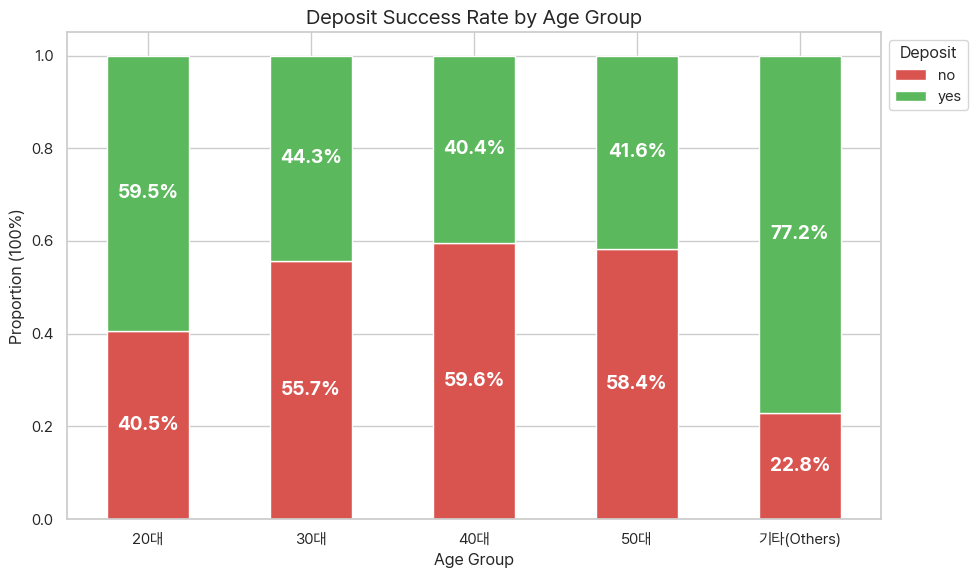

In [56]:
# 행별로 합계가 1(100%)이 되도록 정규화
age_deposit_ratio = pd.crosstab(bank_df['group_category'], bank_df['deposit'], normalize='index')

# 시각화
ax = age_deposit_ratio.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d9534f', '#5cb85c'])

plt.title('Deposit Success Rate by Age Group', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Proportion (100%)')
plt.xticks(rotation=0)
plt.legend(title='Deposit', bbox_to_anchor=(1, 1))

# 비율 수치 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # 0인 경우 표시 안 함
        ax.text(x + width/2, y + height/2, f'{height:.1%}', 
                ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### 그룹 세분화

In [57]:
# 20~50대/other(10대/60대 이상)
main_age_group = [10,20, 30, 40, 50] # 2, 3, 4, 50대
bank_df['group_category'] = bank_df['age_group'].apply(lambda x: f"{int(x)}대" if x in main_age_group else '기타(Others)') 

# 1. 교차표(Contingency Table) 생성
age_deposit_table = pd.crosstab(bank_df['group_category'], bank_df['deposit'])

print("--- 연령대별 가입 빈도 교차표 ---")
display(age_deposit_table)

# 2. 카이제곱 검정
chi2, p_val, dof, expected = chi2_contingency(age_deposit_table)

print(f"\n카이제곱 통계량: {chi2:.6f}")
print(f"p-value: {p_val:.6f}")

# 3. 결과 해석
alpha = 0.05
if p_val < alpha:
    print(f"\n해석: p-value({p_val:.4e})가 0.05보다 작으므로, 연령대에 따른 가입 여부의 차이는 통계적으로 유의미합니다.")
else:
    print(f"\n해석: p-value({p_val:.4f})가 0.05보다 크므로, 연령대와 가입 여부는 독립적(차이 없음)이라고 볼 수 있습니다.")

--- 연령대별 가입 빈도 교차표 ---


deposit,no,yes
group_category,,
10대,3,18
20대,620,910
30대,2405,1913
40대,1565,1063
50대,1100,785
기타(Others),180,600



카이제곱 통계량: 467.149617
p-value: 0.000000

해석: p-value(9.8071e-99)가 0.05보다 작으므로, 연령대에 따른 가입 여부의 차이는 통계적으로 유의미합니다.


In [58]:
cont_table = pd.crosstab(bank_df['group_category'], bank_df['deposit'])
chi2, p, dof, expected = chi2_contingency(cont_table)

# 2. 기대값을 데이터프레임으로 변환
expected_df = pd.DataFrame(expected, index=cont_table.index, columns=cont_table.columns)

# 3. (실제값 - 기대값) 계산: 양수면 예상보다 많이 가입한 것, 음수면 적게 가입한 것
diff = cont_table - expected_df

print("--- 연령대별 가입(yes) 기여도 (실제 - 기대) ---")
display(diff[['yes']].sort_values(by='yes', ascending=False))

--- 연령대별 가입(yes) 기여도 (실제 - 기대) ---


deposit,yes
group_category,
기타(Others),230.404945
20대,185.025085
10대,8.049364
50대,-108.188049
30대,-133.040315
40대,-182.251030


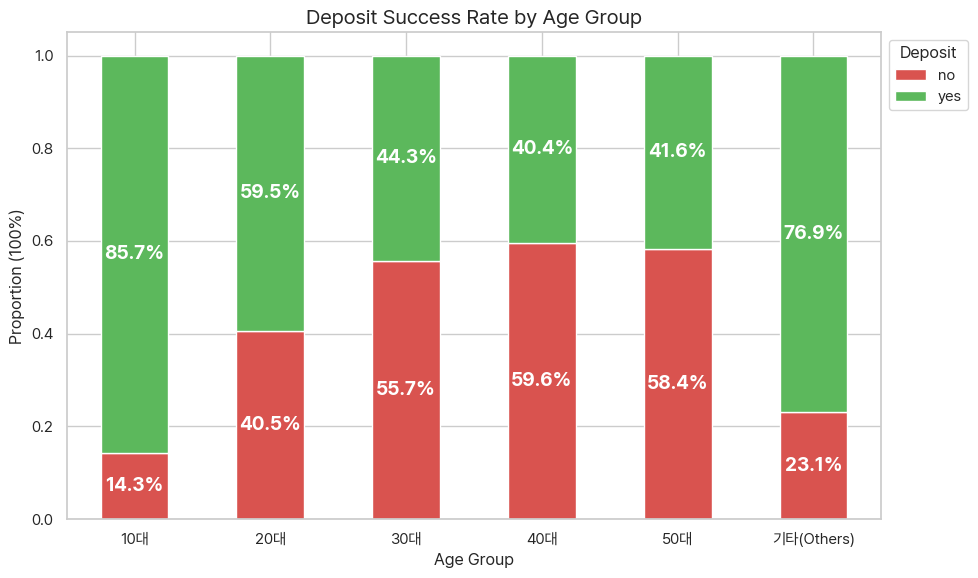

In [59]:
# 행별로 합계가 1(100%)이 되도록 정규화
age_deposit_ratio = pd.crosstab(bank_df['group_category'], bank_df['deposit'], normalize='index')

# 시각화
ax = age_deposit_ratio.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d9534f', '#5cb85c'])

plt.title('Deposit Success Rate by Age Group', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Proportion (100%)')
plt.xticks(rotation=0)
plt.legend(title='Deposit', bbox_to_anchor=(1, 1))

# 비율 수치 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # 0인 경우 표시 안 함
        ax.text(x + width/2, y + height/2, f'{height:.1%}', 
                ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 접촉 이력에 따른 전환률

In [80]:
# 1. 전처리 
# 결측치가 없는 깨끗한 데이터를 사용합니다.
df_pure = bank_df.dropna(subset=['previous_group', 'deposit']).copy()

# 2. 교차표(Contingency Table) 생성
# 행: 접촉 이력 그룹, 열: 가입 여부
cross_tab_pure = pd.crosstab(df_pure['previous_group'], df_pure['deposit'])

print("=== 전체 데이터 접촉 이력별 가입 빈도 ===")
display(cross_tab_pure)

# 3. 카이제곱 검정 수행
chi2, p_value, dof, expected = chi2_contingency(cross_tab_pure)

print(f"\n카이제곱 통계량: {chi2:.2f}")
print(f"p-value: {p_value:.4g}") # 매우 작을 경우 지수 표기법 사용
print(f"자유도: {dof}")

# 4. 결과 해석
if p_value < 0.05:
    print(f"\n[결론] p-value가 {p_value:.4g}로 유의수준 0.05보다 매우 작습니다.")
    print("접촉 이력과 가입 여부 사이에는 '매우 강력한' 통계적 상관관계가 있습니다.")
else:
    print(f"\n[결론] p-value가 {p_value:.4f}로 유의수준 0.05보다 큽니다.")
    print("접촉 이력과 가입 여부 사이에는 통계적으로 유의미한 관계가 발견되지 않았습니다.")

=== 전체 데이터 접촉 이력별 가입 빈도 ===


deposit,no,yes
previous_group,,
new,4940,3384
remarketing,933,1905



카이제곱 통계량: 593.78
p-value: 3.775e-131
자유도: 1

[결론] p-value가 3.775e-131로 유의수준 0.05보다 매우 작습니다.
접촉 이력과 가입 여부 사이에는 '매우 강력한' 통계적 상관관계가 있습니다.


=== 과거 접촉 이력(previous_group)별 CVR 분석 ===


deposit,yes,total,CVR(%)
previous_group,,,
remarketing,1905,2838,67.124736
new,3384,8324,40.653532



카이제곱 통계량: 593.7789
p-value: 3.775e-131
자유도: 1


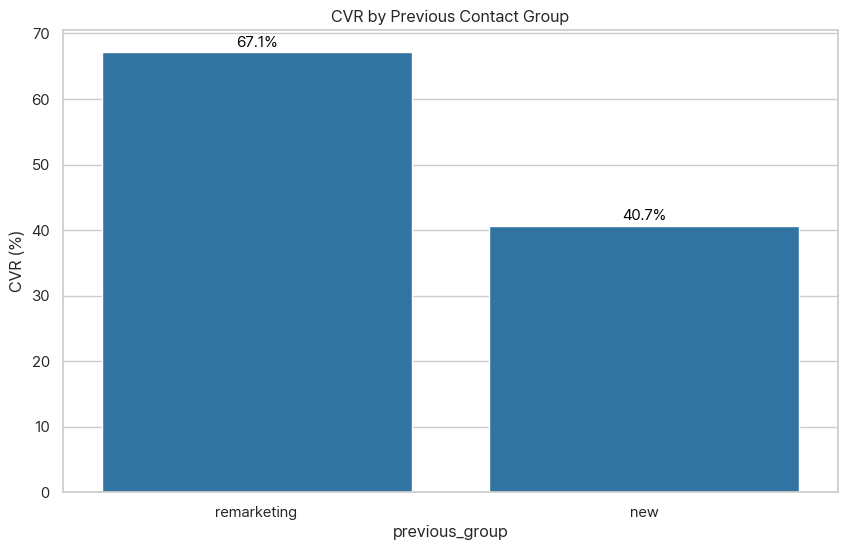

In [78]:
# 1. 교차표 생성 (과거 접촉 그룹별 가입 여부)
cross_tab_prev = pd.crosstab(bank_df['previous_group'], bank_df['deposit'])

# 2. 카이제곱 검정 수행
chi2, p_value, dof, expected = chi2_contingency(cross_tab_prev)

# 3. CVR 계산
cvr_prev = cross_tab_prev.copy()
cvr_prev['total'] = cvr_prev['no'] + cvr_prev['yes']
cvr_prev['CVR(%)'] = (cvr_prev['yes'] / cvr_prev['total']) * 100

# 결과 출력
print("=== 과거 접촉 이력(previous_group)별 CVR 분석 ===")
display(cvr_prev[['yes', 'total', 'CVR(%)']].sort_values(by='CVR(%)', ascending=False))

print(f"\n카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p_value:.4g}")
print(f"자유도: {dof}")

# 4. 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cvr_prev.index, y=cvr_prev['CVR(%)'], order=cvr_prev['CVR(%)'].sort_values(ascending=False).index)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.title("CVR by Previous Contact Group")
plt.ylabel("CVR (%)")
plt.show()

# 맨-휘트니~~휫흐니~~ 검정

## 대출 유무에 따른 차이가 통계적으로 유의한가?

In [62]:
bank_df1 = bank_df.query('balance_group == "plus"').copy()

def define_loan_group(row):
    if row['housing'] == 'no' and row['loan'] == 'no':
        return 'HNLN'
    else:
        return 'Has_Loan'

bank_df1['loan_group'] = bank_df1.apply(define_loan_group, axis=1)

bank_df1['balance_decile'] = pd.qcut(bank_df1['balance'], 10, labels=False)
# 그룹별 가입률 계산
plot_data = bank_df1.groupby(['balance_decile', 'loan_group'])['deposit'].apply(
    lambda x: (x == 'yes').mean()
).unstack()

plot_data.columns = ['대출 미보유','대출 보유']

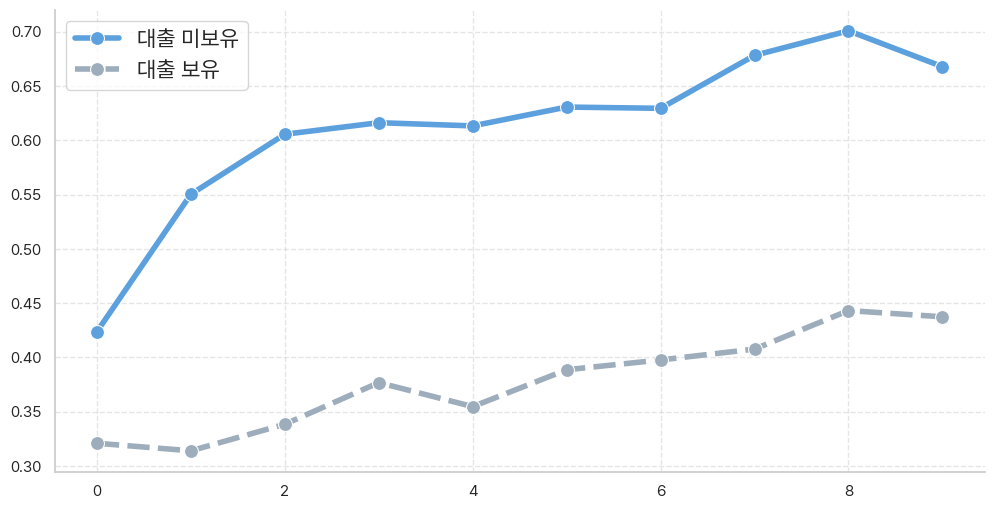

In [63]:
ax = sns.lineplot(data = plot_data, marker = 'o', linewidth=4, markersize=10, palette=['#5ca0de','#9dadbc'])

# plt.title('대출 유무와 잔고 증가량에 따른 예금 가입률', fontsize=16, y = 1.03)
plt.ylabel('')
plt.xlabel('')
plt.legend(fontsize = 16)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()

# 5ca0de
# 9dadbc (기존 회색 톤다운)

plt.savefig('duration_deposit.png', 
            dpi=300,            # PPT에서 안 깨지게 고해상도 설정
            bbox_inches='tight', # 그래프 주변의 불필요한 여백을 싹 제거
            pad_inches=0,        # 여백(padding)을 0으로 설정
            transparent=True)    # 배경을 투명하게 (PPT 배경색과 맞추기 좋음)

plt.show()

In [64]:
bank_df_balance = bank_df.copy()
bank_df_balance['loan_group'] = bank_df_balance['H/L'].apply(lambda x: f"대출 미보유" if x == 'HNLN' else '대출 보유') 
bank_df_depo = bank_df_balance.groupby(['loan_group','deposit']).size().unstack()

bank_df_depo['sum'] = bank_df_depo['no'] + bank_df_depo['yes']
bank_df_depo['yes_rate'] = round((bank_df_depo['yes'] / bank_df_depo['sum']) * 100, 3)
bank_df_depo['no_rate'] = 100 - bank_df_depo['yes_rate']

bank_df_depo.columns = ['가입하지 않음','가입','총계','전환율 (%)', '비전환율 (%)']
bank_df_depo

,가입하지 않음,가입,총계,전환율 (%),비전환율 (%)
loan_group,,,,,
대출 미보유,2121,3135,5256,59.646,40.354
대출 보유,3752,2154,5906,36.471,63.529


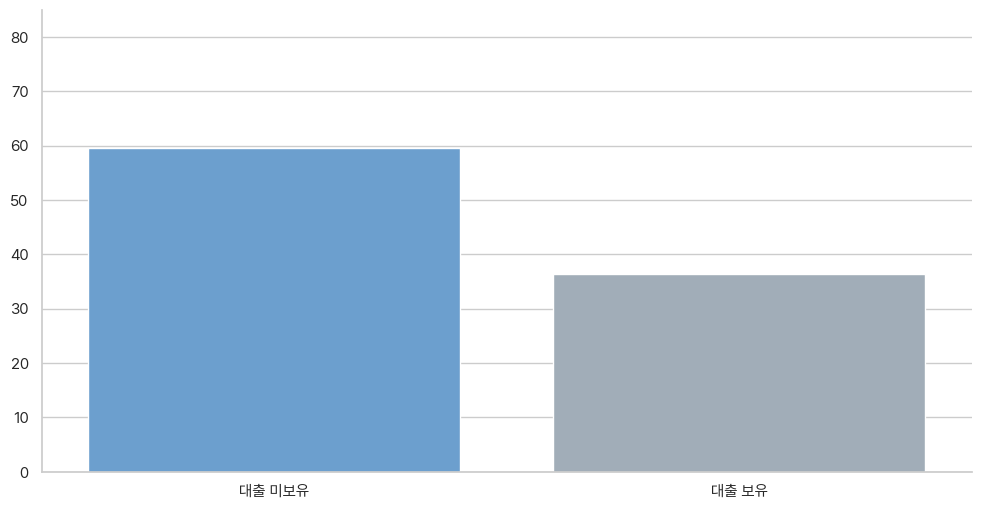

In [85]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(data= bank_df_depo, x='loan_group', y='전환율 (%)',legend=False, hue = 'loan_group', 
                palette=['#5ca0de', '#9dadbc'])

# 각 막대에 수치 추가
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

plt.xlabel('')
plt.ylabel('')
# plt.title('고객 연령대별 예금 가입률', fontsize=16, y = 1.03)
plt.ylim(0, 85)
sns.despine()

plt.savefig('loan_successrate.png', 
            dpi=300,            # PPT에서 안 깨지게 고해상도 설정
            bbox_inches='tight', # 그래프 주변의 불필요한 여백을 싹 제거
            pad_inches=0,        # 여백(padding)을 0으로 설정
            transparent=True)    # 배경을 투명하게 (PPT 배경색과 맞추기 좋음)

plt.show()

### 정규성 검정

In [66]:
# 데이터의 정규성 검정
# 정규성을 따름->T-test, 아님->맨-휘트니

group_yes_loan = plot_data['대출 미보유']
group_no_loan = plot_data['대출 보유']

# 1. 두 집단의 정규성 검정
stat_no, p_no = shapiro(group_no_loan)
stat_yes, p_yes = shapiro(group_yes_loan)

print(f"대출 없는 그룹 정규성 p-value: {p_no:.4e}")
print(f"대출 있는 그룹 정규성 p-value: {p_yes:.4e}")

# 2. 판정
if p_no < 0.05 or p_yes < 0.05:
    print("\n결과: 데이터가 정규성을 만족하지 않으므로 '맨-휘트니 U 검정'이 적절합니다.")
else:
    print("\n결과: 데이터가 정규성을 만족하므로 'T-test'를 고려할 수 있습니다.")

대출 없는 그룹 정규성 p-value: 6.7180e-01
대출 있는 그룹 정규성 p-value: 6.0048e-02

결과: 데이터가 정규성을 만족하므로 'T-test'를 고려할 수 있습니다.


### 시각화(Q-Q plot)

#### 대출 없는 그룹

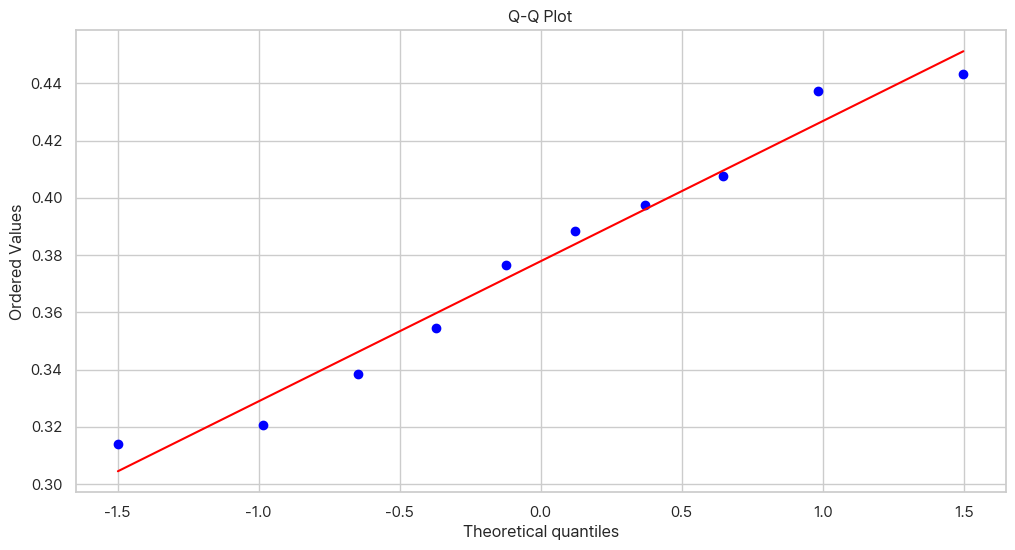

In [67]:
probplot(group_no_loan, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


#### 대출 있는 그룹

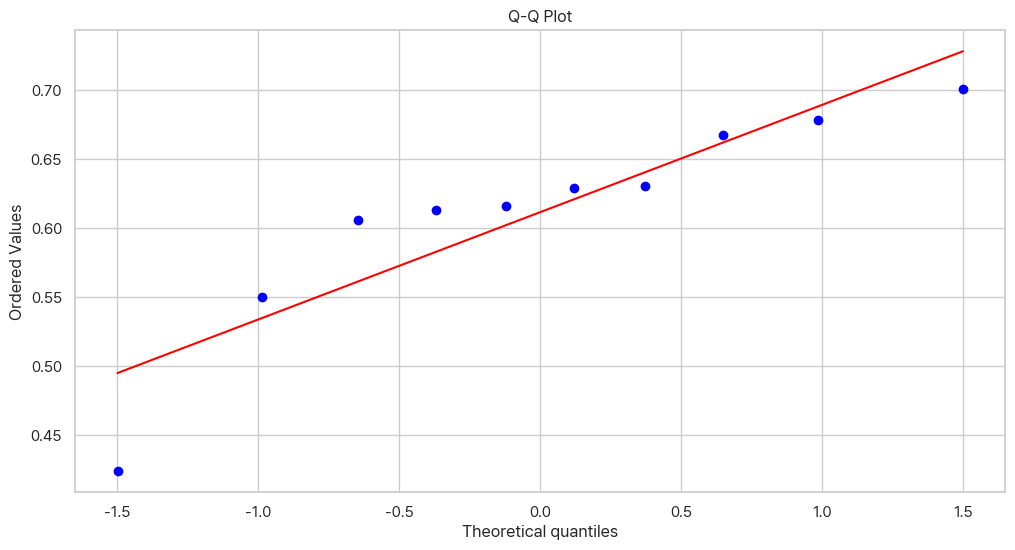

In [68]:
probplot(group_yes_loan, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


In [69]:
# 2. 맨-휘트니 U 검정 수행 (비모수 검정)
u_stat, p_val = stats.mannwhitneyu(group_no_loan, group_yes_loan, alternative='two-sided')

print("=== Mann-Whitney U Test 결과 ===")
print(f"U 통계량: {u_stat:.2f}")
print(f"p-value: {p_val:.4e}") # 지수 표기법으로 출력 (매우 작을 경우 대비)

# 3. 결과 해석
alpha = 0.05
if p_val < alpha:
    print(f"\n[해석] p-value가 {alpha}보다 작으므로, 대출 유무에 따른 두 집단의 CVR 차이는 통계적으로 매우 유의미합니다.")
    print(f"대출 없는 그룹 잔고 중앙값: {group_no_loan.median():.2f}")
    print(f"대출 있는 그룹 잔고 중앙값: {group_yes_loan.median():.2f}")
else:
    print(f"\n[해석] p-value가 {alpha}보다 크므로, 두 집단 간의 CVR 차이가 통계적으로 유의미하다고 볼 수 없습니다.")

=== Mann-Whitney U Test 결과 ===
U 통계량: 2.00
p-value: 3.2984e-04

[해석] p-value가 0.05보다 작으므로, 대출 유무에 따른 두 집단의 CVR 차이는 통계적으로 매우 유의미합니다.
대출 없는 그룹 잔고 중앙값: 0.38
대출 있는 그룹 잔고 중앙값: 0.62


# ANOVA

## 연령대, Contact 횟수별 ANOVA (2-way)

In [82]:
bank_df2 = bank_df.query('20 <= age_group <= 70')

# 1. 그래프와 동일한 집계 데이터(CVR) 생성
def bin_campaign(c):
    if c == 1: return '1'
    elif c == 2: return '2'
    elif c == 3: return '3'
    elif 4 <= c <= 5: return '4-5'
    elif 6 <= c <= 10: return '6-10'
    else: return '11+'

# bank_df1 (plus 잔고 그룹) 기반으로 집계
bank_df2['campaign_bin'] = bank_df2['campaign'].apply(bin_campaign)

# 연령대별, 캠페인 횟수별 CVR 계산
cvr_table = bank_df2.groupby(['age_group', 'campaign_bin'])['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).reset_index(name='cvr')
order = ['1', '2', '3', '4-5', '6-10', '11+']
cvr_table['campaign_bin'] = pd.Categorical(cvr_table['campaign_bin'], categories=order, ordered=True)
cvr_table = cvr_table.sort_values(['age_group', 'campaign_bin'])

display(cvr_table)

# 2. ANOVA 수행 (상호작용 항을 제외한 Additive Model)
# 데이터 포인트가 적을 때는 '*' 대신 '+'를 사용해야 분산 계산이 가능합니다.
# "CVR이 연령대에 따라 다른가? 캠페인 횟수에 따라 다른가?"를 검정합니다.
model = ols('cvr ~ C(age_group) + C(campaign_bin)', data=cvr_table).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print("=== CVR(가입률) 기반 Two-way ANOVA 결과 ===")
print(anova_results.round(2))

/var/folders/wn/f8s0s99540j1nfx5ys7qfd980000gn/T/ipykernel_2150/1416251880.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_df2['campaign_bin'] = bank_df2['campaign'].apply(bin_campaign)


,age_group,campaign_bin,cvr
0,20,1,63.685637
2,20,2,59.712230
3,20,3,57.324841
4,20,4-5,49.285714
5,20,6-10,39.655172
1,20,11+,45.000000
6,30,1,49.116022
8,30,2,42.785235
9,30,3,45.983936
10,30,4-5,37.719298


=== CVR(가입률) 기반 Two-way ANOVA 결과 ===
                   sum_sq    df      F  PR(>F)
C(age_group)     10813.17   5.0  18.73     0.0
C(campaign_bin)   2759.79   5.0   4.78     0.0
Residual          2886.04  25.0    NaN     NaN


In [ ]:
# 캠페인으로 일원분석
model2 = ols('cvr ~ C(campaign_bin)', data=cvr_table).fit()
anova_results2 = sm.stats.anova_lm(model2)

print("=== CVR(가입률) 기반 Two-way ANOVA 결과 ===")
print(anova_results2.round(2))

=== CVR(가입률) 기반 Two-way ANOVA 결과 ===
                   df    sum_sq  mean_sq     F  PR(>F)
C(campaign_bin)   5.0   2759.79   551.96  1.21    0.33
Residual         30.0  13699.21   456.64   NaN     NaN


- 일원분석 하면 빈도로만 했을때는 연령대가 오히려 노이즈가 돼서 잘못된 결론을 내놓더라... 
- 나이로 2-way ANOVA를 하니까 원인이 밝혀졌다

### ANOVA 친구 튜키

In [71]:
# 1. 연령대(age_group)에 대한 사후 검정
print("=== 연령대별 CVR 차이 (Tukey HSD) ===")
tukey_age = pairwise_tukeyhsd(endog=cvr_table['cvr'], groups=cvr_table['age_group'], alpha=0.05)
print(tukey_age)

# 2. 캠페인 횟수(campaign_bin)에 대한 사후 검정
print("\n=== 캠페인 횟수별 CVR 차이 (Tukey HSD) ===")
# 횟수는 우리가 정한 순서대로 비교하기 위해 정렬된 데이터를 사용합니다.
tukey_campaign = pairwise_tukeyhsd(endog=cvr_table['cvr'], groups=cvr_table['campaign_bin'], alpha=0.05)
print(tukey_campaign)

=== 연령대별 CVR 차이 (Tukey HSD) ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    20     30 -13.8477 0.5124 -37.9381 10.2427  False
    20     40 -18.1068  0.231 -42.1972  5.9836  False
    20     50 -18.6793 0.2032 -42.7697  5.4111  False
    20     60   8.5384 0.8862 -15.5521 32.6288  False
    20     70  29.7673 0.0088   5.6768 53.8577   True
    30     40  -4.2591 0.9941 -28.3495 19.8313  False
    30     50  -4.8316 0.9895  -28.922 19.2588  False
    30     60  22.3861 0.0804  -1.7043 46.4765  False
    30     70   43.615 0.0001  19.5245 67.7054   True
    40     50  -0.5725    1.0 -24.6629 23.5179  False
    40     60  26.6452 0.0234   2.5548 50.7356   True
    40     70  47.8741    0.0  23.7836 71.9645   True
    50     60  27.2177 0.0197   3.1273 51.3081   True
    50     70  48.4466    0.0  24.3562  72.537   True
    60     70  21.2289 0.1092  -2.8615 45.3193  Fa

### 시각화

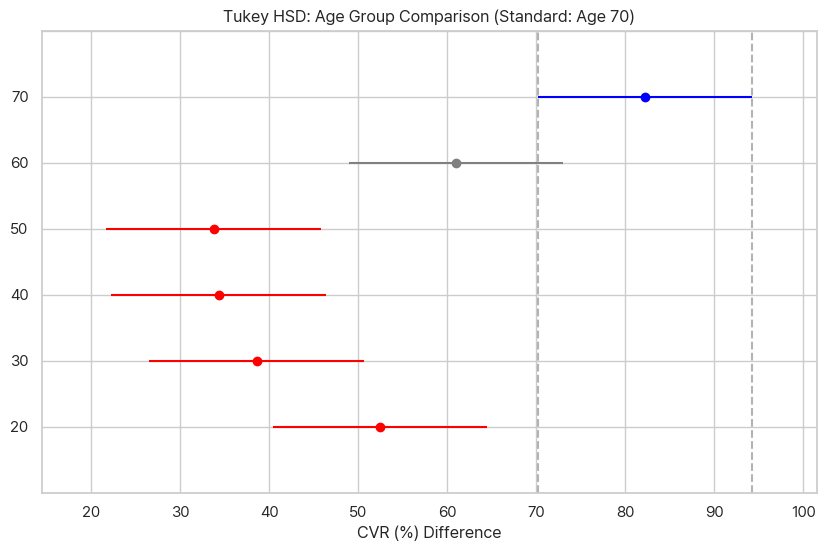

In [72]:
# 연령대 튜키 결과 시각화
fig = tukey_age.plot_simultaneous(comparison_name=70, figsize=(10, 6))
plt.title("Tukey HSD: Age Group Comparison (Standard: Age 70)")
plt.xlabel("CVR (%) Difference")
plt.show()

/var/folders/wn/f8s0s99540j1nfx5ys7qfd980000gn/T/ipykernel_2150/4277764824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='campaign_bin', y='cvr', data=cvr_table, palette='Blues')


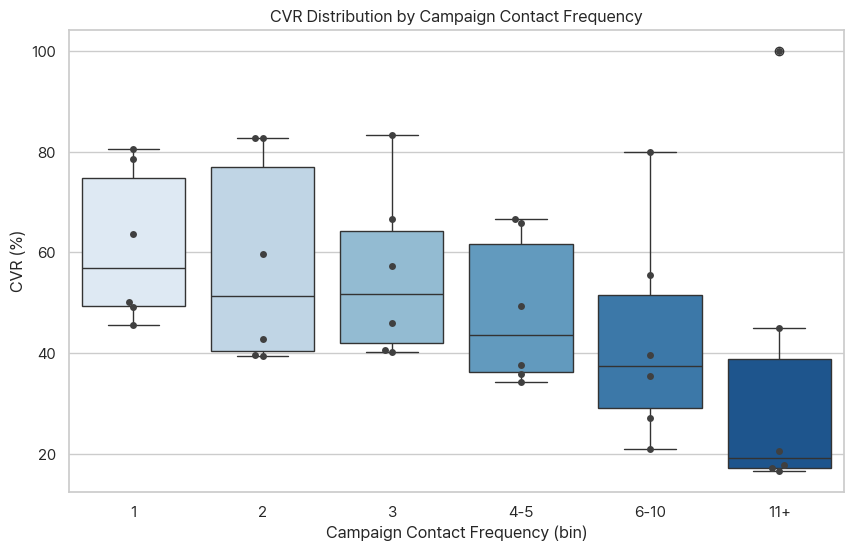

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='campaign_bin', y='cvr', data=cvr_table, palette='Blues')
sns.swarmplot(x='campaign_bin', y='cvr', data=cvr_table, color=".25") # 실제 CVR 점들 추가
plt.title("CVR Distribution by Campaign Contact Frequency")
plt.ylabel("CVR (%)")
plt.xlabel("Campaign Contact Frequency (bin)")
plt.show()

# 상관분서억

## 스피어만 상관분석(대출 유무와 deposit)
- deposit이 범주형 데이터인데, 범주형 데이터에는 스피어만 상관분석을 합니다. 

In [83]:
# 대출 그룹에 따른 deposit
corr_data = bank_df1[['loan_group','deposit']].copy()

# 범주형 데이터 더미화
# 대출 없음: 1, 있음: 0
# 가입 예스: 1, 노: 0
corr_data['loan_dummy'] = corr_data['loan_group'].apply(lambda x: 1 if x == 'HNLN' else 0)
corr_data['deposit_dummy'] = corr_data['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

# 스피어만 상관계수 분석
spearman_corr_matrix = corr_data[['loan_dummy','deposit_dummy']].corr(method='spearman')
display(spearman_corr_matrix.round(2))

,loan_dummy,deposit_dummy
loan_dummy,1.00,0.24
deposit_dummy,0.24,1.00


- 대출유무와 가입률간에는 약한 양의 상관관계가 있다. 

## 피어슨 상관계수(잔고 분위별 CVR)

In [75]:
# 잔고가 +인 사람
bank_df1 = bank_df.query('balance_group == "plus"').copy()

def define_loan_group(row):
    if row['housing'] == 'no' and row['loan'] == 'no':
        return 'HNLN'
    else:
        return 'Has_Loan'

bank_df1['loan_group'] = bank_df1.apply(define_loan_group, axis=1)

bank_df1['balance_decile'] = pd.qcut(bank_df1['balance'], 10, labels=False)
# 그룹별 가입률 계산
plot_data = bank_df1.groupby(['balance_decile', 'loan_group'])['deposit'].apply(
    lambda x: (x == 'yes').mean()
).unstack()

plot_data.columns = ['대출 미보유','대출 보유']

plot_data

,대출 미보유,대출 보유
balance_decile,,
0,0.423690,0.320826
1,0.550351,0.313869
2,0.605568,0.338346
3,0.616228,0.376699
4,0.613272,0.354597
5,0.630631,0.388571
6,0.629474,0.397590
7,0.678245,0.407583
8,0.700901,0.443099


In [84]:
# 잔고 레벨이 인덱스로 빠져서... 
plot_data_reset = plot_data.reset_index()

plot_data_corr = plot_data_reset.corr()
display(plot_data_corr.round(2))

,balance_decile,대출 미보유,대출 보유
balance_decile,1.00,0.86,0.97
대출 미보유,0.86,1.00,0.83
대출 보유,0.97,0.83,1.00


- 잔고등급에 따른 대출 미보유자의 상관계수: 0.85
- 잔고 등급에 따른 대출 보유자의 상관계수: 0.96
> 부채가 있는 고객일수록 가용 자산의 규모에 따라 가입 의사결정을 보수적이고 규칙적으로 내리고 있음